# MSCS 634 — Project Deliverable 1
## Data Collection, Cleaning, and Exploration

**Dataset:** Clickstream Data for Online Shopping (UCI ML Repository, ID 553)  
**Group Member:** Mohammed Sajjad Mohammed Arif Ansari, Hoai Nam Tran  
**Course:** Advanced Big Data and Data Mining

---

## 1. Dataset and Justification

Browsing activity from an online store selling clothing for pregnant women,
April–August 2008: **165,474 click records across 14 attributes**.

We chose it because it supports all four analyses the project requires:
`price` gives a regression target (D2), `main_category` a four-class classification
target (D3), session aggregates the features for clustering (D3) — and each session
is already a basket of clicks, so association rules can be mined without the
artificial discretisation most datasets need.

**Attributes:** `year`, `month`, `day`; `session ID`, `order`; `country` (from IP);
`page 1 (main category)`, `page 2 (clothing model)`, `colour`, `price`; `location`,
`model photography`, `page`; `price 2`.

## 2. Loading and Inspection

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="deep")

# The file uses semicolon delimiters (European convention), not commas
df = pd.read_csv("e-shop clothing 2008.csv", sep=";")

df = df.rename(columns={
    "order": "click_order", "country": "country_code", "session ID": "session_id",
    "page 1 (main category)": "main_category", "page 2 (clothing model)": "clothing_model",
    "colour": "colour_code", "location": "photo_location",
    "model photography": "model_photography", "price 2": "price_above_avg",
    "page": "page_number",
})

print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns\n")
pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_null": df.isnull().sum(),
})

Loaded 165,474 rows x 14 columns



,dtype,n_unique,n_null
year,int64,1,0
month,int64,5,0
day,int64,31,0
click_order,int64,195,0
country_code,int64,47,0
session_id,int64,24026,0
main_category,int64,4,0
clothing_model,object,217,0
colour_code,int64,14,0
photo_location,int64,6,0


Four problems are visible immediately:

1. `year` has one unique value (2008) — zero variance.
2. Most categoricals are stored as integers. `country_code`, `main_category`,
   `colour_code`, `photo_location`, `model_photography`, `price_above_avg` and
   `page_number` are labels encoded as numbers, so pandas treats them as continuous —
   `describe()` would report a mean colour code of about 7, which means nothing.
3. The date is split across three columns.
4. `clothing_model` has 217 levels.


## 3. Data Cleaning

### 3.1 Dropping `year`, recoding categoricals, assembling the date

The recoding matters most: left as integers, these attributes would make regression
models in D2 impose an arbitrary linear ordering on unordered categories, and
distance-based methods in D3 (K-Means, k-NN) compute meaningless distances.
Mappings come from `e-shop clothing 2008 data description.txt`.

`page_number` is deliberately kept numeric, it is genuinely ordinal, since page 3
is deeper into the site than page 2.

In [4]:
df = df.drop(columns=["year"])   # constant at 2008

maps = {
    "main_category": {1: "trousers", 2: "skirts", 3: "blouses", 4: "sale"},
    "colour_code": {1: "beige", 2: "black", 3: "blue", 4: "brown", 5: "burgundy",
                    6: "gray", 7: "green", 8: "navy blue", 9: "many colours",
                    10: "olive", 11: "pink", 12: "red", 13: "violet", 14: "white"},
    "photo_location": {1: "top left", 2: "top middle", 3: "top right",
                       4: "bottom left", 5: "bottom middle", 6: "bottom right"},
    "model_photography": {1: "en face", 2: "profile"},
    "price_above_avg": {1: "yes", 2: "no"},
    "country_code": {
        1: "Australia", 2: "Austria", 3: "Belgium", 4: "British Virgin Islands",
        5: "Cayman Islands", 6: "Christmas Island", 7: "Croatia", 8: "Cyprus",
        9: "Czech Republic", 10: "Denmark", 11: "Estonia", 12: "unidentified",
        13: "Faroe Islands", 14: "Finland", 15: "France", 16: "Germany", 17: "Greece",
        18: "Hungary", 19: "Iceland", 20: "India", 21: "Ireland", 22: "Italy",
        23: "Latvia", 24: "Lithuania", 25: "Luxembourg", 26: "Mexico",
        27: "Netherlands", 28: "Norway", 29: "Poland", 30: "Portugal", 31: "Romania",
        32: "Russia", 33: "San Marino", 34: "Slovakia", 35: "Slovenia", 36: "Spain",
        37: "Sweden", 38: "Switzerland", 39: "Ukraine", 40: "United Arab Emirates",
        41: "United Kingdom", 42: "USA", 43: "biz", 44: "com", 45: "int",
        46: "net", 47: "org"},
}

# Verify every observed code has a mapping before applying
for col, m in maps.items():
    unmapped = set(df[col].unique()) - set(m.keys())
    print(f"{col:<20} unmapped: {sorted(unmapped) if unmapped else 'none'}")

df["colour"] = df["colour_code"].map(maps["colour_code"])
df["country"] = df["country_code"].map(maps["country_code"])
for col in ["main_category", "photo_location", "model_photography", "price_above_avg"]:
    df[col] = df[col].map(maps[col])
df = df.drop(columns=["colour_code"])

# Assemble date - also validates it (month 4 day 31 would give NaT)
df["date"] = pd.to_datetime(dict(year=2008, month=df["month"], day=df["day"]),
                            errors="coerce")
df["weekday"] = df["date"].dt.day_name()
print(f"\nInvalid dates: {df['date'].isna().sum()}   "
      f"Range: {df['date'].min().date()} to {df['date'].max().date()}")

main_category        unmapped: none
colour_code          unmapped: none
photo_location       unmapped: none
model_photography    unmapped: none
price_above_avg      unmapped: none
country_code         unmapped: none

Invalid dates: 0   Range: 2008-04-01 to 2008-08-13


### 3.2 Missing values 

The description file lists 47 country codes, and **code 12 is `unidentified`** — an
IP that could not be resolved. That is a missing value, but stored as a valid
integer inside the normal code range it could not be found by `isnull(). It is findable only by reading the
documentation: **the data dictionary is part of the data.**

In [5]:
# The documentation is what finds it
n_unid = int((df["country_code"] == 12).sum())
print(f"\nCountry code 12 (unidentified): {n_unid:,} records "
      f"({100 * n_unid / len(df):.3f}%)")

# Treatment: flag the attribute, keep the records
df["country_known"] = df["country_code"] != 12
df.loc[df["country_code"] == 12, "country"] = np.nan

# Duplicates: identical content rows are legitimate (a user can click the same
# product twice). The meaningful check is the session/order key.
print(f"Duplicated (session_id, click_order): "
      f"{df.duplicated(subset=['session_id', 'click_order']).sum()}")

# Country is dominated by one market - group by observed frequency
freq = df["country_code"].value_counts()
major = freq[freq >= 0.005 * len(df)].index.tolist()
df["country_group"] = np.where(
    ~df["country_known"], "unidentified",
    np.where(df["country_code"] == freq.index[0], "domestic",
             np.where(df["country_code"].isin(major), "major_foreign", "other_foreign")))

print(f"\nDominant market: {maps['country_code'][freq.index[0]]} "
      f"({100 * freq.iloc[0] / len(df):.1f}% of clicks)")


Country code 12 (unidentified): 210 records (0.127%)
Duplicated (session_id, click_order): 0

Dominant market: Poland (81.0% of clicks)


**Treatment: retain the records, flag the attribute.** Dropping them would discard
complete, valid observations of category, colour, price and page depth over an
attribute most of the analysis does not use. `country_known` makes the exclusion
explicit wherever country is involved.

### Cleaning summary

- **Semicolon-delimited file** — loaded with `sep=";"`
- **`year` constant at 2008** — dropped (zero variance)
- **Six categoricals stored as integers** — recoded to labels; `page_number` kept ordinal
- **Date split across three columns** — assembled and validated
- **Country code 12 = `unidentified`** — 210 records flagged, `country` set to `NaN`
- **Duplicates** — session/order key verified; content repeats retained as genuine
- **Country imbalance** — grouped by observed frequency

## 4. Unit of Analysis

Each row is one **click**, but our questions are about **sessions**.

That matters because models treat each row as a separate observation. A visitor who
clicks 50 times would count 50 times, while one who clicks twice counts twice, so
heavy browsers would dominate the results.

We therefore collapsed the clicks into one row per session, keeping both versions:
click level for association rules and screen-position analysis, session level for
clustering and session outcomes.

In [ ]:
sessions = df.groupby("session_id").agg(
    n_clicks=("click_order", "count"),
    max_page=("page_number", "max"),
    n_categories=("main_category", "nunique"),
    n_products=("clothing_model", "nunique"),
    n_colours=("colour", "nunique"),
    mean_price=("price", "mean"),
    max_price=("price", "max"),
    min_price=("price", "min"),
    country_group=("country_group", "first"),
    weekday=("weekday", "first"),
    date=("date", "first"),
).reset_index()

sessions["price_range"] = sessions["max_price"] - sessions["min_price"]

sessions["dominant_category"] = sessions["session_id"].map(
    df.groupby(["session_id", "main_category"]).size().reset_index(name="n")
      .sort_values(["session_id", "n"], ascending=[True, False])
      .drop_duplicates("session_id").set_index("session_id")["main_category"])

# Engineered classification target.
# outcome - this dataset records browsing only.
sessions["deep_session"] = np.where(sessions["max_page"] >= 3, "deep", "shallow")

print(f"{len(df):,} clicks -> {len(sessions):,} sessions "
      f"({len(df)/len(sessions):.2f} each)\n")
print((sessions["deep_session"].value_counts(normalize=True) * 100).round(1).to_string())

165,474 clicks -> 24,026 sessions (6.89 each)

deep_session
shallow    62.0
deep       38.0


## 5. Outlier Detection

Assessed at **session** level — a single click cannot meaningfully be an outlier,
but a session of several hundred clicks is a genuine anomaly. Both the IQR rule
(1.5 × IQR) and z-scores are applied, since each has a distinct weakness.

In [5]:
num_cols = ["n_clicks", "max_page", "n_categories", "n_products",
            "mean_price", "price_range"]

rows = []
for col in num_cols:
    q1, q3 = sessions[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (sessions[col] < q1 - 1.5*iqr) | (sessions[col] > q3 + 1.5*iqr)
    z = ((sessions[col] - sessions[col].mean()) / sessions[col].std()).abs()
    rows.append({"feature": col, "median": sessions[col].median(),
                 "max": sessions[col].max(), "skew": round(sessions[col].skew(), 2),
                 "IQR_outliers": int(mask.sum()), "z>3": int((z > 3).sum())})

sessions["log_n_clicks"] = np.log1p(sessions["n_clicks"])
sessions["is_extreme"] = sessions["n_clicks"] > sessions["n_clicks"].quantile(0.99)
pd.DataFrame(rows)

,feature,median,max,skew,IQR_outliers,z>3
0,n_clicks,4.000000,195.0,4.88,1962,467
1,max_page,2.000000,5.0,0.67,0,0
2,n_categories,2.000000,4.0,0.79,0,0
3,n_products,4.000000,168.0,4.53,1582,473
4,mean_price,43.666667,82.0,0.46,405,139
5,price_range,24.000000,64.0,0.23,0,0


**Decision: retain all sessions.** A long session is not a measurement error, it is
a visitor who browsed extensively, precisely the behaviour of interest. Removing
them would delete the most informative records and bias results toward casual
browsers.

The right skew is a property of the process, not a defect: web session lengths are
characteristically heavy-tailed, and the IQR rule assumes rough symmetry, so here it
flags the distribution's natural shape. Extreme sessions were **flagged** instead,
and a log transform prepared for the scale-sensitive clustering in D3.

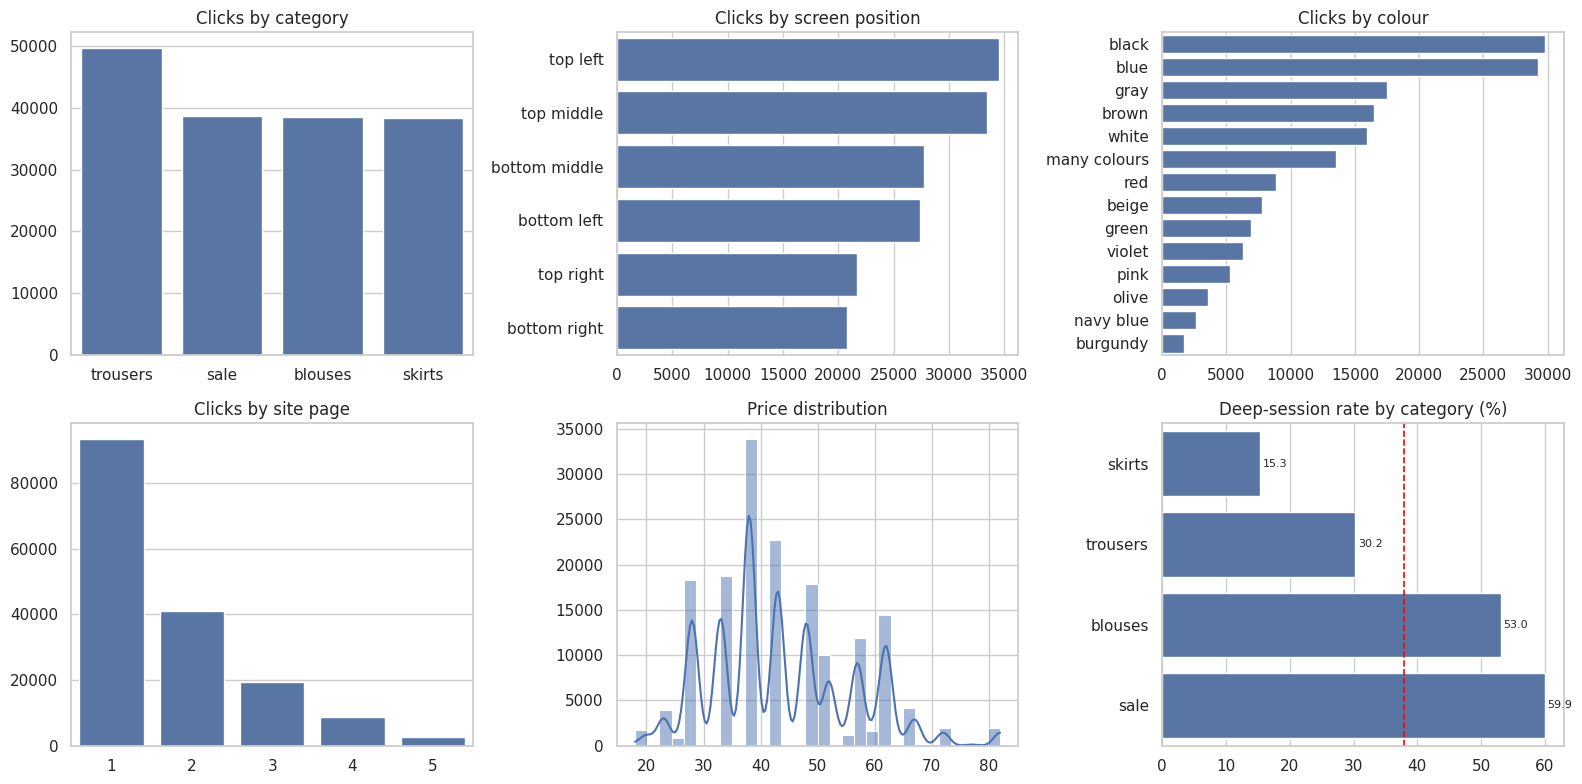

                mean  median  count
main_category                      
blouses        40.29    43.0  38577
sale           36.23    38.0  38747
skirts         51.19    52.0  38408
trousers       46.71    43.0  49742


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

sns.countplot(data=df, x="main_category",
              order=df["main_category"].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title("Clicks by category")

sns.countplot(data=df, y="photo_location",
              order=df["photo_location"].value_counts().index, ax=axes[0, 1])
axes[0, 1].set_title("Clicks by screen position")

sns.countplot(data=df, y="colour",
              order=df["colour"].value_counts().index, ax=axes[0, 2])
axes[0, 2].set_title("Clicks by colour")

sns.countplot(data=df, x="page_number", ax=axes[1, 0])
axes[1, 0].set_title("Clicks by site page")

sns.histplot(df["price"], bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Price distribution")

rate = (sessions.groupby("dominant_category")["deep_session"]
        .apply(lambda s: (s == "deep").mean() * 100).sort_values())
sns.barplot(x=rate.values, y=rate.index, ax=axes[1, 2], orient="h")
axes[1, 2].axvline((sessions["deep_session"] == "deep").mean() * 100,
                   color="red", linestyle="--", lw=1.2)
axes[1, 2].set_title("Deep-session rate by category (%)")
for cont in axes[1, 2].containers:
    axes[1, 2].bar_label(cont, fmt="%.1f", fontsize=8, padding=2)

for ax in axes.ravel():
    ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()

print(df.groupby("main_category")["price"].agg(["mean", "median", "count"]).round(2).to_string())

### 6.1. Cecking whether `price` can actually be predicted

`price` is the obvious choice for my D2 regression target, but we need to check one
thing first: does each product always cost the same?

If product A13 is always $28, then the product code doesn't help *predict* price,
it just tells you the answer directly, like looking it up in a price list. A model
using it would score almost perfectly while learning nothing. The check below counts
how many different prices each product actually has.

In [7]:
g = df.groupby("clothing_model")["price"].agg(["nunique", "std"]).fillna(0)
print(f"Products:                        {len(g)}")
print(f"Products with exactly one price: {(g['nunique'] == 1).sum()} "
      f"({100 * (g['nunique'] == 1).mean():.1f}%)")
print(f"Mean within-product price std:   {g['std'].mean():.4f}")
print(f"Overall price std:               {df['price'].std():.4f}")

Products:                        217
Products with exactly one price: 217 (100.0%)
Mean within-product price std:   0.0000
Overall price std:               12.5481


**Every one of the 217 products has exactly one price**, zero within-product
variance. Not a strong correlation — an identity. `clothing_model` is a 217-row
lookup table for price stored in a different column.

**Decision for D2: exclude `clothing_model`**, and also `price_above_avg`, which is
derived arithmetically from `price`.

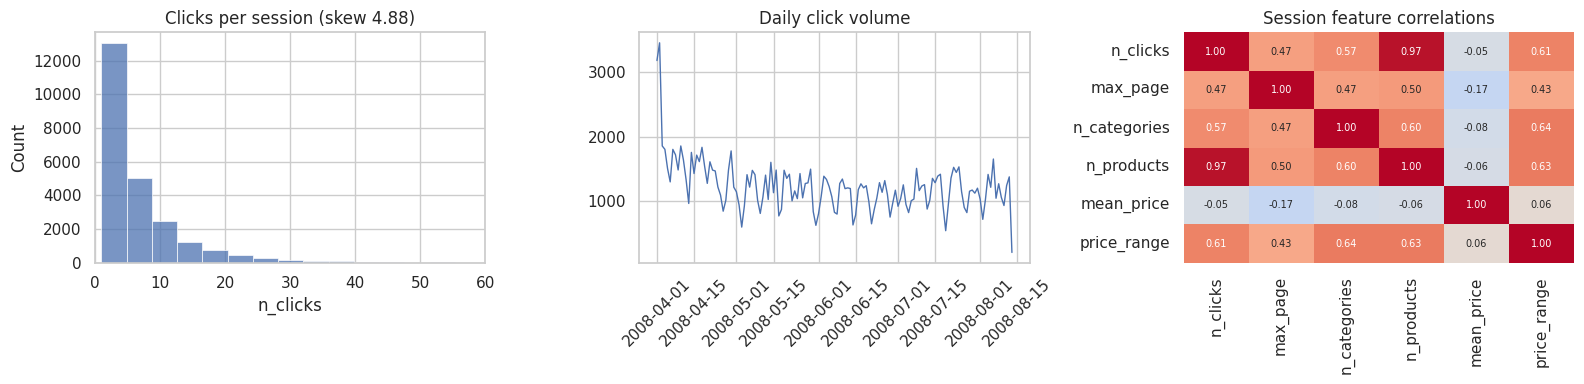

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(sessions["n_clicks"], bins=50, ax=axes[0])
axes[0].set_xlim(0, 60)
axes[0].set_title(f"Clicks per session (skew {sessions['n_clicks'].skew():.2f})")

daily = df.groupby("date").size()
axes[1].plot(daily.index, daily.values, lw=1)
axes[1].set_title("Daily click volume")
axes[1].tick_params(axis="x", rotation=45)

sns.heatmap(sessions[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[2], cbar=False, annot_kws={"size": 7})
axes[2].set_title("Session feature correlations")

plt.tight_layout(); plt.show()

## 7. Insights and Implications

**1. Six categoricals stored as integers** was the most serious data quality issue —
it would have corrupted both regression and distance-based methods silently, with no
error message.

**2. The dataset had missing values despite documentation to the contrary** (country
code 12, 210 records). No programmatic check would have found them.

**3. Unit of analysis was the key preparation decision** — 165,474 clicks collapse
to 24,026 sessions.

**4. Traffic is 81% domestic (Poland)**, so international findings rest on a small
minority of records.

**5. `price` is completely determined by `clothing_model`** — excluded from D2.

In [9]:
df.to_csv("clickstream_clean_click_level.csv", index=False)
sessions.to_csv("clickstream_clean_session_level.csv", index=False)
print(f"click-level:   {df.shape[0]:,} x {df.shape[1]}")
print(f"session-level: {sessions.shape[0]:,} x {sessions.shape[1]}")

click-level:   165,474 x 18
session-level: 24,026 x 17
